**Library Imports**

In [1]:
import re
import random
import pandas as pd
import numpy as np
import csv
from pathlib import Path

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer, BertModel, DistilBertTokenizerFast, DistilBertForSequenceClassification

import gensim.downloader as api
from gensim.models import Word2Vec, FastText

import matplotlib.pyplot as plt
import seaborn as sns

**Set Device type**

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


**Load Dataset**

In [3]:
df = pd.read_csv('dataset/support-ticket-classification-2000.csv')

y = np.array(df['label'].values)
unique_labels = sorted(df['label'].unique().tolist())

print(f"Dataset loaded: {df.shape}")
print(f"Classes: {unique_labels}")
print(f"Class distribution:\n{df['label'].value_counts()}\n")

Dataset loaded: (2000, 4)
Classes: ['account_access', 'billing', 'bug_report', 'refund_request', 'shipping_delivery']
Class distribution:
label
account_access       400
billing              400
refund_request       400
bug_report           400
shipping_delivery    400
Name: count, dtype: int64



**Preprocessing Steps**

In [4]:
def load_stopwords(file_path):
    stopwords = set()
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            word = line.strip().lower()
            if word and not word.startswith('#'):
                stopwords.add(word)
    return stopwords

stopwords = load_stopwords('dataset/stopwords.txt')

for w in ['the', 'is', 'account', 'billing', 'login', 'and', 'password']:
    print(f"{w} -> stopword: {w in stopwords}")

the -> stopword: True
is -> stopword: True
account -> stopword: False
billing -> stopword: False
login -> stopword: False
and -> stopword: True
password -> stopword: False


In [5]:
def load_exc_files(noun_file, verb_file):
    exc_map = {}
    for file_path in [noun_file, verb_file]:
        if not Path(file_path).exists():
            continue
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    exc_map[parts[0]] = parts[1]
    return exc_map

exc_map = load_exc_files('dataset/wordnet_noun.exc', 'dataset/wordnet_verb.exc')

for word in ['men', 'mice', 'geese', 'ran', 'is']:
    if word in exc_map:
        print(f"{word} -> {exc_map[word]}")

men -> man
mice -> mouse
geese -> goose
ran -> run
is -> be


In [6]:
def load_lemma_dict(file_path):
    lemma_map = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(';') or ' -> ' not in line:
                continue
            lemma_part, _, forms_part = line.partition(' -> ')
            lemma = lemma_part.split('/')[0].strip()
            for form in forms_part.split(','):
                form = form.strip()
                if form and re.match(r'^[a-z0-9]+$', form) and form not in lemma_map:
                    lemma_map[form] = lemma
    return lemma_map

lemma_map = load_lemma_dict('dataset/lemma.en.txt')
print(f"lemma_map loaded: {len(lemma_map)} entries\n")

for word in ['running', 'categories', 'responses', 'presses']:
    print(f"{word} -> {lemma_map.get(word, '(not found)')}")

lemma_map loaded: 90502 entries

running -> run
categories -> category
responses -> response
presses -> press


In [7]:
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "don't": "do not",
    "doesn't": "does not", "didn't": "did not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "you're": "you are", "we're": "we are",
    "they're": "they are", "it's": "it is", "that's": "that is",
    "there's": "there is", "i've": "i have", "we've": "we have",
    "they've": "they have", "shouldn't": "should not", "couldn't": "could not",
    "wouldn't": "would not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not",
}

for k, v in list(CONTRACTIONS.items())[:3]:
    print(f"{k} -> {v}")

can't -> cannot
won't -> will not
don't -> do not


In [8]:
DOMAIN_PHRASE_MAP = {
    "log in": "login", "sign in": "login",
    "wireless": "wifi", "wifi": "wifi",
    "remote access": "vpn", "vpn": "vpn",
    "mfa": "mfa", "2fa": "mfa",
}

DOMAIN_TOKEN_MAP = {
    "pls": "please", "plz": "please", "asap": "urgent",
    "u": "you", "ur": "your", "pwd": "password",
    "acct": "account", "acc": "account", "auth": "authentication",
    "db": "database", "srv": "server", "msg": "message",
    "req": "request", "otp": "onetimepassword", "2fa": "mfa",
}

for k, v in list(DOMAIN_PHRASE_MAP.items())[:3]:
    print(f"phrase  {k} -> {v}")
for k, v in list(DOMAIN_TOKEN_MAP.items())[:3]:
    print(f"token   {k} -> {v}")

phrase  log in -> login
phrase  sign in -> login
phrase  wireless -> wifi
token   pls -> please
token   plz -> please
token   asap -> urgent


In [9]:
NEGATION_TOKENS = {"no", "not", "never", "cannot", "failed", "unable", "without"}
DOMAIN_STOPWORDS = {"hi", "hello", "dear", "team", "please", "kindly", "thanks", "thank", "regards", "best", "sir", "madam"}
ALLOWED_TOKEN_PUNCT = set(".-/@#+_:\\")

for w in ['cannot', 'not', 'hello', 'billing', 'please', 'account']:
    print(f"{w}  negation={w in NEGATION_TOKENS}  stopword={w in DOMAIN_STOPWORDS}")

cannot  negation=True  stopword=False
not  negation=True  stopword=False
hello  negation=False  stopword=True
billing  negation=False  stopword=False
please  negation=False  stopword=True
account  negation=False  stopword=False


In [10]:
REPLY_CHAIN_PATTERN = re.compile(r"^\s*on\s+.+\s+wrote:\s*$", flags=re.IGNORECASE)
HEADER_PATTERN = re.compile(r"^\s*(from|sent|to|cc|bcc|date)\s*:", flags=re.IGNORECASE)
SIGNATURE_PATTERN = re.compile(
    r"^\s*(thanks|thank you|regards|best regards|kind regards|sincerely|cheers)[\s,!.-]*$",
    flags=re.IGNORECASE,
)
DISCLAIMER_PATTERN = re.compile(
    r"(this\s+(e-?mail|message).{0,120}(confidential|intended only)|please\s+do\s+not\s+reply|"
    r"automatically\s+generated|auto-?generated)",
    flags=re.IGNORECASE,
)

samples = [
    ("On Mon Apr 12 user@x.com wrote:", REPLY_CHAIN_PATTERN, "reply_chain"),
    ("From: user@example.com",          HEADER_PATTERN,      "header"),
    ("Thanks,",                          SIGNATURE_PATTERN,   "signature"),
    ("This email is auto-generated",     DISCLAIMER_PATTERN,  "disclaimer"),
]
for text, pattern, label in samples:
    print(f"{label} {'✓' if pattern.search(text) else '✗'}  {text}")

reply_chain ✓  On Mon Apr 12 user@x.com wrote:
header ✓  From: user@example.com
signature ✓  Thanks,
disclaimer ✓  This email is auto-generated


In [11]:
ENTITY_TAG_PATTERNS = [
    ("IP_ADDR",    re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")),
    ("TICKET_ID",  re.compile(r"\b(?:inc|ticket|case|ref|req)[-_:#\s]*\d{3,}\b", flags=re.IGNORECASE)),
    ("ORDER_ID",   re.compile(r"\b(?:order|ord)[-_:#\s]*\d{3,}\b", flags=re.IGNORECASE)),
    ("VERSION",    re.compile(r"\bv\d+(?:\.\d+){1,3}\b", flags=re.IGNORECASE)),
    ("ERROR_CODE", re.compile(r"\b(?:0x[a-fA-F0-9]{4,}|(?:error|err|errno|exception)[-_:#\s]*[a-z0-9_-]{2,})\b", flags=re.IGNORECASE)),
    ("LONG_NUM",   re.compile(r"\b\d{6,}\b")),
]

TOKEN_PATTERN = re.compile(
    r"(?:https?://\S+|www\.\S+)|"
    r"(?:[A-Za-z]:\\[^\s]+)|"
    r"(?:[\w.+-]+@[\w.-]+\.\w+)|"
    r"(?:\b\w+(?:[._:/\\#@+-]\w+)+\b)|"
    r"(?:\b\w+\b)"
)

sample = "Error 0x1234ABCD on ticket INC-5432 from 192.168.1.1, order 98765, v1.2.3"
for tag, pattern in ENTITY_TAG_PATTERNS:
    m = pattern.search(sample)
    if m:
        print(f"{tag} matched: {m.group(0)}")

IP_ADDR matched: 192.168.1.1
TICKET_ID matched: INC-5432
ORDER_ID matched: order 98765
VERSION matched: v1.2.3
ERROR_CODE matched: Error 0x1234ABCD


In [12]:
def normalize_whitespace(text, keep_newlines=False):
    if keep_newlines:
        text = re.sub(r"[^\S\n]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        return text.strip()
    return re.sub(r"\s+", " ", text).strip()

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\u200b", " ")
    text = re.sub(r"[\t\f\v]+", " ", text)
    return normalize_whitespace(text, keep_newlines=True)

def remove_boilerplate(text):
    lines = [line.strip() for line in text.split("\n")]
    kept_lines = []
    for idx, line in enumerate(lines):
        if not line:
            continue
        if REPLY_CHAIN_PATTERN.match(line):
            break
        if HEADER_PATTERN.match(line):
            continue
        if DISCLAIMER_PATTERN.search(line):
            continue
        if SIGNATURE_PATTERN.match(line) and idx >= max(2, len(lines) // 3):
            break
        kept_lines.append(line)
    return normalize_whitespace("\n".join(kept_lines))

sample_email = "From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\nOn Mon Apr 12 support@company.com wrote:\n> Previous message here."
print("raw   :", repr(sample_email[:80]))
print("clean :", repr(clean_text(sample_email)[:80]))
print("boiler:", repr(remove_boilerplate(clean_text(sample_email))[:80]))

raw   : 'From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\n'
clean : 'From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\n'
boiler: 'I cannot login to my account.'


In [13]:
def expand_contractions(text):
    for contraction, expanded in CONTRACTIONS.items():
        text = re.sub(rf"\b{re.escape(contraction)}\b", expanded, text, flags=re.IGNORECASE)
    return text

def apply_domain_mapping(text, phrase_map=None):
    phrase_map = phrase_map or DOMAIN_PHRASE_MAP
    for source, target in phrase_map.items():
        text = re.sub(rf"\b{re.escape(source)}\b", target, text, flags=re.IGNORECASE)
    return text

samples = [
    "I can't log in with 2fa",
    "Won't connect over wireless",
    "Please sign in using remote access",
]
for s in samples:
    print(f"{s} -> {apply_domain_mapping(expand_contractions(s))}")

I can't log in with 2fa -> I cannot login with mfa
Won't connect over wireless -> will not connect over wifi
Please sign in using remote access -> Please login using vpn


In [14]:
def normalize_entities(text, add_tags=True):
    if not add_tags:
        return text
    for tag, pattern in ENTITY_TAG_PATTERNS:
        text = pattern.sub(lambda m: f" {m.group(0)} {tag} ", text)
    return normalize_whitespace(text)

def tokenize(text):
    return TOKEN_PATTERN.findall(text)

def normalize_token(token, lowercase=True):
    token = token.strip("\"'`()[]{}<> ").strip(".,;!?")
    if not token:
        return ""
    if token.isalpha():
        token = re.sub(r"(.)\1{2,}", r"\1\1", token)
    mapped = DOMAIN_TOKEN_MAP.get(token.lower())
    if mapped is not None:
        return mapped
    return token.lower() if lowercase else token

def is_identifier_like(token):
    if not token:
        return False
    if token.isupper() and len(token) > 1:
        return True
    if any(ch.isdigit() for ch in token):
        return True
    if any(ch in ALLOWED_TOKEN_PUNCT for ch in token):
        return True
    return False

sample = "Error 0x1234ABCD on ticket INC-5432 from 192.168.1.1, pls fix asap"
print("entities :", normalize_entities(sample))
print("tokens   :", tokenize(sample)[:8])
print("normed   :", [normalize_token(t) for t in tokenize(sample)[:6]])

entities : Error 0x1234ABCD ERROR_CODE on ticket INC-5432 TICKET_ID from 192.168.1.1 IP_ADDR , pls fix asap
tokens   : ['Error', '0x1234ABCD', 'on', 'ticket', 'INC-5432', 'from', '192.168.1.1', 'pls']
normed   : ['error', '0x1234abcd', 'on', 'ticket', 'inc-5432', 'from']


In [15]:
def should_lemmatize(token):
    if token in NEGATION_TOKENS:
        return False
    if not token.isalpha() or len(token) < 4:
        return False
    if is_identifier_like(token):
        return False
    if token.endswith(("ing", "ed")):
        return False
    return True

def postprocess_tokens(tokens, lemma_map=None, exc_map=None, remove_stopwords=True, stopwords=None):
    if stopwords is None:
        stopwords = set()
    processed = []
    for token in tokens:
        token = normalize_token(token, lowercase=True)
        if len(token) <= 1:
            continue
        if remove_stopwords and token in stopwords and token not in NEGATION_TOKENS:
            continue
        if should_lemmatize(token):
            lemma = exc_map.get(token) if exc_map else None
            if lemma is None and lemma_map:
                lemma = lemma_map.get(token)
            if lemma:
                token = lemma
        if remove_stopwords and token in stopwords and token not in NEGATION_TOKENS:
            continue
        processed.append(token)
    return processed

tokens = ['running', 'accounts', 'the', 'categories', 'pls', 'cannot', 'responses']
result = postprocess_tokens(tokens, lemma_map=lemma_map, exc_map=exc_map, remove_stopwords=True, stopwords=DOMAIN_STOPWORDS)
print(f"before : {tokens}")
print(f"after  : {result}")

before : ['running', 'accounts', 'the', 'categories', 'pls', 'cannot', 'responses']
after  : ['running', 'account', 'the', 'category', 'cannot', 'response']


In [16]:
def preprocess_for_bert(text):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=False)
    text = normalize_whitespace(text)
    text = text.lower()
    return text

def preprocess_for_tfidf(text, lemma_map=None, exc_map=None):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=True)
    tokens = tokenize(text)
    tokens = postprocess_tokens(tokens, lemma_map=lemma_map, exc_map=exc_map, remove_stopwords=True, stopwords=DOMAIN_STOPWORDS)
    return " ".join(tokens)

def preprocess_for_embedding(text):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=False)
    tokens = tokenize(text)
    tokens = postprocess_tokens(tokens, lemma_map=None, exc_map=None, remove_stopwords=False, stopwords=set())
    return " ".join(tokens)

sample = "SUBJECT: Can't login to account BODY: I'm trying to sign in but getting error 0x401 on ticket INC-9921"
print(f"raw    : {sample}")
print(f"bert   : {preprocess_for_bert(sample)}")
print(f"tfidf  : {preprocess_for_tfidf(sample, lemma_map=lemma_map, exc_map=exc_map)}")
print(f"embed  : {preprocess_for_embedding(sample)}")

raw    : SUBJECT: Can't login to account BODY: I'm trying to sign in but getting error 0x401 on ticket INC-9921
bert   : subject: cannot login to account body: i am trying to login but getting error 0x401 on ticket inc-9921
tfidf  : subject cannot login to account body am trying to login but getting error 0x401 error_code on ticket inc-9921 ticket_id
embed  : subject cannot login to account body am trying to login but getting error 0x401 on ticket inc-9921


In [17]:
def compose_ticket_text(subject, text):
    subject = "" if pd.isna(subject) else str(subject).strip()
    text = "" if pd.isna(text) else str(text).strip()
    return f"SUBJECT: {subject} BODY: {text}".strip()

raw_texts, bert_texts, tfidf_texts, embedding_texts = [], [], [], []

for idx in range(len(df)):
    raw = compose_ticket_text(df.iloc[idx]['subject'], df.iloc[idx]['text'])
    raw_texts.append(raw)
    bert_texts.append(preprocess_for_bert(raw))
    tfidf_texts.append(preprocess_for_tfidf(raw, lemma_map=lemma_map, exc_map=exc_map))
    embedding_texts.append(preprocess_for_embedding(raw))

df['raw_text']       = raw_texts
df['bert_text']      = bert_texts
df['tfidf_text']     = tfidf_texts
df['embedding_text'] = embedding_texts

x_train, x_test, y_train, y_test = train_test_split(
    np.arange(len(df)), y, test_size=0.25, stratify=y,
)

print(f"Train: {len(x_train)} samples  |  Test: {len(x_test)} samples\n")

sample_idx = x_train[0]
print(f"raw   : {df.iloc[sample_idx]['raw_text'][:120]}")
print(f"bert  : {df.iloc[sample_idx]['bert_text'][:120]}")
print(f"tfidf : {df.iloc[sample_idx]['tfidf_text'][:120]}")
print(f"embed : {df.iloc[sample_idx]['embedding_text'][:120]}")

Train: 1500 samples  |  Test: 500 samples

raw   : SUBJECT: Product significantly different from description BODY: The product I received looks and functions nothing like 
bert  : subject: product significantly different from description body: the product i received looks and functions nothing like 
tfidf : subject product significantly different from description body the product received look and function nothing like what w
embed : subject product significantly different from description body the product received looks and functions nothing like what


**TF-IDF Training Step**

In [18]:
class TFIDFExtractor:
    def __init__(self, word_max=35000, char_max=20000):
        self.word_max = word_max
        self.char_max = char_max
        self.word_vec = TfidfVectorizer(
            lowercase=True, analyzer='word', ngram_range=(1, 2),
            min_df=2, max_df=0.95, sublinear_tf=True,
            strip_accents='unicode', max_features=word_max
        )
        self.char_vec = TfidfVectorizer(
            lowercase=True, analyzer='char_wb', ngram_range=(3, 5),
            min_df=2, sublinear_tf=True, max_features=char_max
        )
    
    def fit(self, texts):
        self.word_vec.fit(texts)
        self.char_vec.fit(texts)
        return self
    
    def transform(self, texts):
        X_word = self.word_vec.transform(texts)
        X_char = self.char_vec.transform(texts)
        return hstack([X_word, X_char]).tocsr()

In [19]:
train_texts_prep = df.iloc[x_train]['tfidf_text'].values
test_texts_prep = df.iloc[x_test]['tfidf_text'].values
train_texts_raw = df.iloc[x_train]['raw_text'].values
test_texts_raw = df.iloc[x_test]['raw_text'].values

extractor_prep = TFIDFExtractor(word_max=35000, char_max=20000)
extractor_prep.fit(train_texts_prep)
X_train_tfidf_prep = extractor_prep.transform(train_texts_prep)
X_test_tfidf_prep = extractor_prep.transform(test_texts_prep)

extractor_raw = TFIDFExtractor(word_max=35000, char_max=20000)
extractor_raw.fit(train_texts_raw)
X_train_tfidf_raw = extractor_raw.transform(train_texts_raw)
X_test_tfidf_raw = extractor_raw.transform(test_texts_raw)

print(f"Preprocessed TF-IDF: {X_train_tfidf_prep.shape} (train), {X_test_tfidf_prep.shape} (test)")
print(f"Raw TF-IDF:         {X_train_tfidf_raw.shape} (train), {X_test_tfidf_raw.shape} (test)")

Preprocessed TF-IDF: (1500, 20263) (train), (500, 20263) (test)
Raw TF-IDF:         (1500, 22874) (train), (500, 22874) (test)


In [20]:
results_raw = {}

print("TF-IDF (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_tfidf_raw, y_train)
    y_pred = clf.predict(X_test_tfidf_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results_raw[clf_name] = {'accuracy': accuracy, 'macro_f1': macro_f1}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}  Macro-F1: {macro_f1:.4f}")

TF-IDF (Raw)

SVM                       Accuracy: 0.9260  Macro-F1: 0.9260
Logistic Regression       Accuracy: 0.9200  Macro-F1: 0.9200
KNN                       Accuracy: 0.9000  Macro-F1: 0.8992


In [21]:
results_prep = {}

print("TF-IDF (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_tfidf_prep, y_train)
    y_pred = clf.predict(X_test_tfidf_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results_prep[clf_name] = {'accuracy': accuracy, 'macro_f1': macro_f1}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}  Macro-F1: {macro_f1:.4f}")

TF-IDF (Preprocessed)

SVM                       Accuracy: 0.9280  Macro-F1: 0.9280
Logistic Regression       Accuracy: 0.9220  Macro-F1: 0.9219
KNN                       Accuracy: 0.9020  Macro-F1: 0.9015


**Word2Vec**

In [22]:
def scale_dense_features(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

def get_avg_embedding(text, keyed_vectors, vector_size):
    words = text.split()
    vectors = [keyed_vectors[word] for word in words if word in keyed_vectors]
    if not vectors:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0)

def build_embedding_feature_pair(df, train_idx, test_idx, keyed_vectors, vector_size, prep_col='embedding_text', raw_col='raw_text'):
    X_train_prep = np.array([get_avg_embedding(df.iloc[i][prep_col], keyed_vectors, vector_size) for i in train_idx])
    X_test_prep = np.array([get_avg_embedding(df.iloc[i][prep_col], keyed_vectors, vector_size) for i in test_idx])
    X_train_raw = np.array([get_avg_embedding(df.iloc[i][raw_col], keyed_vectors, vector_size) for i in train_idx])
    X_test_raw = np.array([get_avg_embedding(df.iloc[i][raw_col], keyed_vectors, vector_size) for i in test_idx])

    X_train_prep, X_test_prep = scale_dense_features(X_train_prep, X_test_prep)
    X_train_raw, X_test_raw = scale_dense_features(X_train_raw, X_test_raw)
    return X_train_prep, X_test_prep, X_train_raw, X_test_raw

def train_local_word2vec(sentences, vector_size=300, epochs=45):
    local_model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=5,
        min_count=1,
        sg=1,
        workers=4,
        epochs=epochs,
    )
    return local_model.wv

print("Loading pretrained Word2Vec (Google News 300d)...")
train_sentences_embedding = [df.iloc[i]['embedding_text'].split() for i in x_train]
try:
    w2v_vectors = api.load("word2vec-google-news-300")
    w2v_dim = w2v_vectors.vector_size
    print(f"Pretrained Word2Vec loaded: {w2v_dim}-dimensional")
except Exception as ex:
    print(f"Pretrained Word2Vec unavailable ({ex}). Training local fallback model...")
    w2v_vectors = train_local_word2vec(train_sentences_embedding, vector_size=300, epochs=55)
    w2v_dim = w2v_vectors.vector_size
    print(f"Local Word2Vec trained: {w2v_dim}-dimensional")

Loading pretrained Word2Vec (Google News 300d)...
Pretrained Word2Vec loaded: 300-dimensional


In [23]:
print("Creating Word2Vec vectors for preprocessed and raw text...")
X_train_embed_prep, X_test_embed_prep, X_train_embed_raw, X_test_embed_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    w2v_vectors,
    w2v_dim,
    prep_col='embedding_text',
    raw_col='raw_text',
)

print(f"Word2Vec (Preprocessed): {X_train_embed_prep.shape} (train), {X_test_embed_prep.shape} (test)")
print(f"Word2Vec (Raw):         {X_train_embed_raw.shape} (train), {X_test_embed_raw.shape} (test)")

Creating Word2Vec vectors for preprocessed and raw text...
Word2Vec (Preprocessed): (1500, 300) (train), (500, 300) (test)
Word2Vec (Raw):         (1500, 300) (train), (500, 300) (test)


In [24]:
results_embed_raw = {}

print("Word2Vec (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_raw, y_train)
    y_pred = clf.predict(X_test_embed_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results_embed_raw[clf_name] = {'accuracy': accuracy, 'macro_f1': macro_f1}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}  Macro-F1: {macro_f1:.4f}")

Word2Vec (Raw)

SVM                       Accuracy: 0.9000  Macro-F1: 0.9001
Logistic Regression       Accuracy: 0.8760  Macro-F1: 0.8758
KNN                       Accuracy: 0.8540  Macro-F1: 0.8525


In [25]:
results_embed_prep = {}

print("Word2Vec (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_prep, y_train)
    y_pred = clf.predict(X_test_embed_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results_embed_prep[clf_name] = {'accuracy': accuracy, 'macro_f1': macro_f1}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}  Macro-F1: {macro_f1:.4f}")

Word2Vec (Preprocessed)

SVM                       Accuracy: 0.8840  Macro-F1: 0.8839
Logistic Regression       Accuracy: 0.8820  Macro-F1: 0.8816
KNN                       Accuracy: 0.8780  Macro-F1: 0.8761


**FastText**

In [26]:
def preprocess_for_fasttext(text):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=False)
    tokens = tokenize(text)
    tokens = postprocess_tokens(tokens, lemma_map=None, exc_map=None, remove_stopwords=False, stopwords=set())
    return " ".join(tokens)

fasttext_prep_texts = []
for idx in range(len(df)):
    raw = compose_ticket_text(df.iloc[idx]['subject'], df.iloc[idx]['text'])
    fasttext_prep_texts.append(preprocess_for_fasttext(raw))

df['fasttext_text'] = fasttext_prep_texts

print(f"Added fasttext_text column")
sample_idx = x_train[0]
print(f"raw      : {df.iloc[sample_idx]['raw_text'][:100]}")
print(f"fasttext : {df.iloc[sample_idx]['fasttext_text'][:100]}")

Added fasttext_text column
raw      : SUBJECT: Product significantly different from description BODY: The product I received looks and fun
fasttext : subject product significantly different from description body the product received looks and functio


In [27]:
print("Training FastText embeddings (subword-aware)...")

train_sentences_fasttext_prep = [df.iloc[i]['fasttext_text'].split() for i in x_train]
train_sentences_fasttext_raw = [df.iloc[i]['raw_text'].lower().split() for i in x_train]

fasttext_prep = FastText(
    vector_size=220,
    window=5,
    min_count=1,
    sg=1,
    min_n=3,
    max_n=6,
    workers=4,
)
fasttext_prep.build_vocab(train_sentences_fasttext_prep)
fasttext_prep.train(train_sentences_fasttext_prep, total_examples=len(train_sentences_fasttext_prep), epochs=55)

fasttext_raw = FastText(
    vector_size=220,
    window=5,
    min_count=1,
    sg=1,
    min_n=3,
    max_n=6,
    workers=4,
)
fasttext_raw.build_vocab(train_sentences_fasttext_raw)
fasttext_raw.train(train_sentences_fasttext_raw, total_examples=len(train_sentences_fasttext_raw), epochs=55)

print("Creating FastText vectors for preprocessed and raw text...")
X_train_embed_ft_prep, X_test_embed_ft_prep, X_train_embed_ft_raw, X_test_embed_ft_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    fasttext_prep.wv,
    fasttext_prep.vector_size,
    prep_col='fasttext_text',
    raw_col='raw_text',
)

print(f"FastText (Preprocessed): {X_train_embed_ft_prep.shape} (train), {X_test_embed_ft_prep.shape} (test)")
print(f"FastText (Raw):         {X_train_embed_ft_raw.shape} (train), {X_test_embed_ft_raw.shape} (test)")

Training FastText embeddings (subword-aware)...
Creating FastText vectors for preprocessed and raw text...
FastText (Preprocessed): (1500, 220) (train), (500, 220) (test)
FastText (Raw):         (1500, 220) (train), (500, 220) (test)


In [28]:
results_ft_raw = {}

print("FastText (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_ft_raw, y_train)
    y_pred = clf.predict(X_test_embed_ft_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results_ft_raw[clf_name] = {'accuracy': accuracy, 'macro_f1': macro_f1}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}  Macro-F1: {macro_f1:.4f}")

FastText (Raw)

SVM                       Accuracy: 0.8980  Macro-F1: 0.8980
Logistic Regression       Accuracy: 0.8800  Macro-F1: 0.8800
KNN                       Accuracy: 0.8840  Macro-F1: 0.8830


In [29]:
results_ft_prep = {}

print("FastText (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_ft_prep, y_train)
    y_pred = clf.predict(X_test_embed_ft_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results_ft_prep[clf_name] = {'accuracy': accuracy, 'macro_f1': macro_f1}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}  Macro-F1: {macro_f1:.4f}")

FastText (Preprocessed)

SVM                       Accuracy: 0.9040  Macro-F1: 0.9041
Logistic Regression       Accuracy: 0.8920  Macro-F1: 0.8920
KNN                       Accuracy: 0.9000  Macro-F1: 0.8993


In [30]:
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.to(device)
bert_model.eval()

bert_batch_size = 24 if device.type == 'cuda' else 10
bert_max_length = 192

print(f"BERT loaded (output dimension: 768, batch_size={bert_batch_size}, max_length={bert_max_length})")

def extract_bert_features(texts, tokenizer, model, device, batch_size=16, max_length=192):
    features = []
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            
            encodings = tokenizer(
                batch_texts,
                add_special_tokens=True,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors='pt'
            )
            
            input_ids = encodings['input_ids'].to(device)
            attention_mask = encodings['attention_mask'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            token_embeddings = outputs.last_hidden_state
            mask_expanded = attention_mask.unsqueeze(-1).float()
            sum_embeddings = (token_embeddings * mask_expanded).sum(dim=1)
            sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
            batch_features = (sum_embeddings / sum_mask).cpu().numpy()
            features.extend(batch_features)
    
    return np.array(features)

C:\Users\HSPR\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


BERT loaded (output dimension: 768, batch_size=24, max_length=192)


In [31]:
print("Extracting BERT features from preprocessed text...")
train_texts_bert_prep = df.iloc[x_train]['bert_text'].tolist()
test_texts_bert_prep = df.iloc[x_test]['bert_text'].tolist()
X_train_embed_bert_prep = extract_bert_features(
    train_texts_bert_prep, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_test_embed_bert_prep = extract_bert_features(
    test_texts_bert_prep, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_train_embed_bert_prep, X_test_embed_bert_prep = scale_dense_features(X_train_embed_bert_prep, X_test_embed_bert_prep)

print("Extracting BERT features from raw text...")
train_texts_bert_raw = df.iloc[x_train]['raw_text'].tolist()
test_texts_bert_raw = df.iloc[x_test]['raw_text'].tolist()
X_train_embed_bert_raw = extract_bert_features(
    train_texts_bert_raw, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_test_embed_bert_raw = extract_bert_features(
    test_texts_bert_raw, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_train_embed_bert_raw, X_test_embed_bert_raw = scale_dense_features(X_train_embed_bert_raw, X_test_embed_bert_raw)

print(f"BERT (Preprocessed): {X_train_embed_bert_prep.shape} (train), {X_test_embed_bert_prep.shape} (test)")
print(f"BERT (Raw):         {X_train_embed_bert_raw.shape} (train), {X_test_embed_bert_raw.shape} (test)")

Extracting BERT features from preprocessed text...


C:\Users\HSPR\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\models\bert\modeling_bert.py:439: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Extracting BERT features from raw text...
BERT (Preprocessed): (1500, 768) (train), (500, 768) (test)
BERT (Raw):         (1500, 768) (train), (500, 768) (test)


In [32]:
results_bert_raw = {}

print("BERT (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_bert_raw, y_train)
    y_pred = clf.predict(X_test_embed_bert_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results_bert_raw[clf_name] = {'accuracy': accuracy, 'macro_f1': macro_f1}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}  Macro-F1: {macro_f1:.4f}")

BERT (Raw)

SVM                       Accuracy: 0.8940  Macro-F1: 0.8940
Logistic Regression       Accuracy: 0.8960  Macro-F1: 0.8952
KNN                       Accuracy: 0.8800  Macro-F1: 0.8787


In [33]:
results_bert_prep = {}

print("BERT (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_bert_prep, y_train)
    y_pred = clf.predict(X_test_embed_bert_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    results_bert_prep[clf_name] = {'accuracy': accuracy, 'macro_f1': macro_f1}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}  Macro-F1: {macro_f1:.4f}")

BERT (Preprocessed)

SVM                       Accuracy: 0.8940  Macro-F1: 0.8938
Logistic Regression       Accuracy: 0.8920  Macro-F1: 0.8910
KNN                       Accuracy: 0.8720  Macro-F1: 0.8706


In [34]:
all_results = {
    'TF-IDF (Preprocessed)': results_prep,
    'TF-IDF (Raw)': results_raw,
    'Word2Vec (Raw)': results_embed_raw,
    'Word2Vec (Preprocessed)': results_embed_prep,
    'FastText (Raw)': results_ft_raw,
    'FastText (Preprocessed)': results_ft_prep,
    'BERT (Raw)': results_bert_raw,
    'BERT (Preprocessed)': results_bert_prep,
}

accuracy_data = {}
f1_data = {}

for feature_name, clf_results in all_results.items():
    accuracy_data[feature_name] = {clf: clf_results[clf]['accuracy'] for clf in clf_results}
    f1_data[feature_name] = {clf: clf_results[clf]['macro_f1'] for clf in clf_results}

accuracy_df = pd.DataFrame(accuracy_data).T
f1_df = pd.DataFrame(f1_data).T

accuracy_df

,SVM,Logistic Regression,KNN
TF-IDF (Preprocessed),0.928,0.922,0.902
TF-IDF (Raw),0.926,0.920,0.900
Word2Vec (Raw),0.900,0.876,0.854
Word2Vec (Preprocessed),0.884,0.882,0.878
FastText (Raw),0.898,0.880,0.884
FastText (Preprocessed),0.904,0.892,0.900
BERT (Raw),0.894,0.896,0.880
BERT (Preprocessed),0.894,0.892,0.872


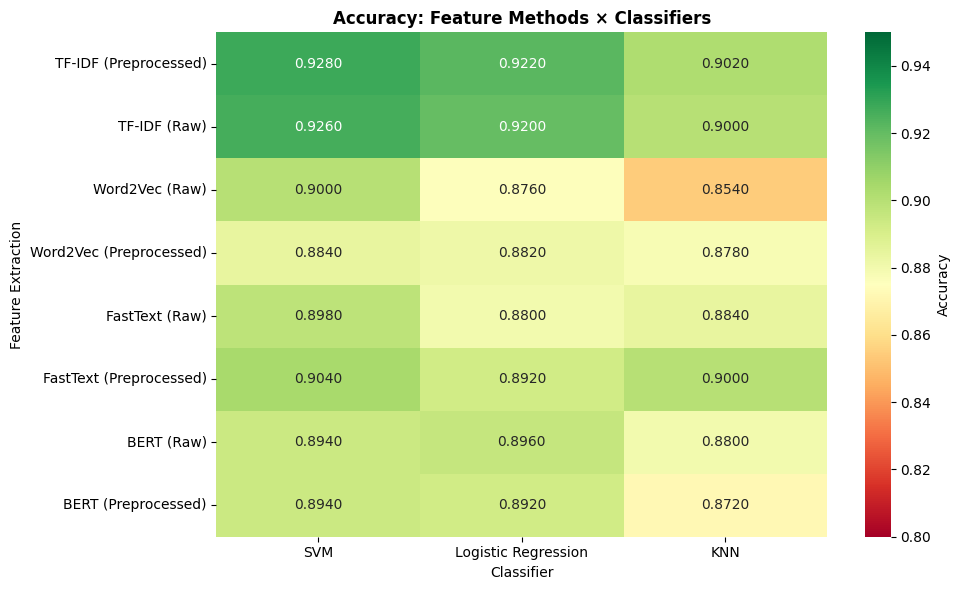

In [35]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    accuracy_df,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Accuracy'},
    vmin=0.8,
    vmax=0.95
)
plt.title('Accuracy: Feature Methods × Classifiers', fontsize=12, fontweight='bold')
plt.xlabel('Classifier')
plt.ylabel('Feature Extraction')
plt.tight_layout()
plt.show()

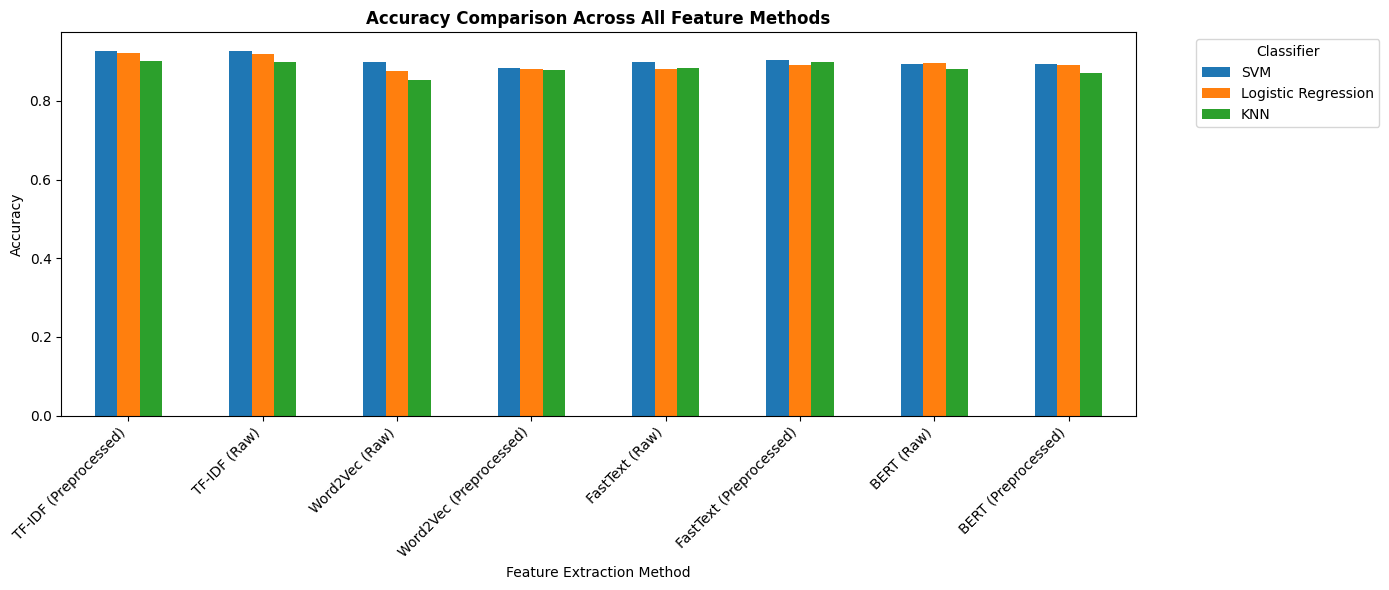

In [36]:
fig, ax = plt.subplots(figsize=(14, 6))

accuracy_df.plot(kind='bar', ax=ax)
ax.set_title('Accuracy Comparison Across All Feature Methods', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Feature Extraction Method')
ax.legend(title='Classifier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
rankings = []

for feature_name in accuracy_df.index:
    for clf_name in accuracy_df.columns:
        acc = accuracy_df.loc[feature_name, clf_name]
        f1 = f1_df.loc[feature_name, clf_name]
        rankings.append((feature_name, clf_name, acc, f1))

rankings.sort(key=lambda x: x[2], reverse=True)

ranking_df = pd.DataFrame(rankings, columns=['Feature', 'Classifier', 'Accuracy', 'Macro-F1'])
ranking_df['Rank'] = range(1, len(ranking_df) + 1)
ranking_df = ranking_df[['Rank', 'Feature', 'Classifier', 'Accuracy', 'Macro-F1']]

ranking_df.head(10)

,Rank,Feature,Classifier,Accuracy,Macro-F1
0,1,TF-IDF (Preprocessed),SVM,0.928,0.927980
1,2,TF-IDF (Raw),SVM,0.926,0.925995
2,3,TF-IDF (Preprocessed),Logistic Regression,0.922,0.921939
3,4,TF-IDF (Raw),Logistic Regression,0.920,0.919999
4,5,FastText (Preprocessed),SVM,0.904,0.904107
5,6,TF-IDF (Preprocessed),KNN,0.902,0.901453
6,7,TF-IDF (Raw),KNN,0.900,0.899183
7,8,Word2Vec (Raw),SVM,0.900,0.900119
8,9,FastText (Preprocessed),KNN,0.900,0.899336
9,10,FastText (Raw),SVM,0.898,0.898039


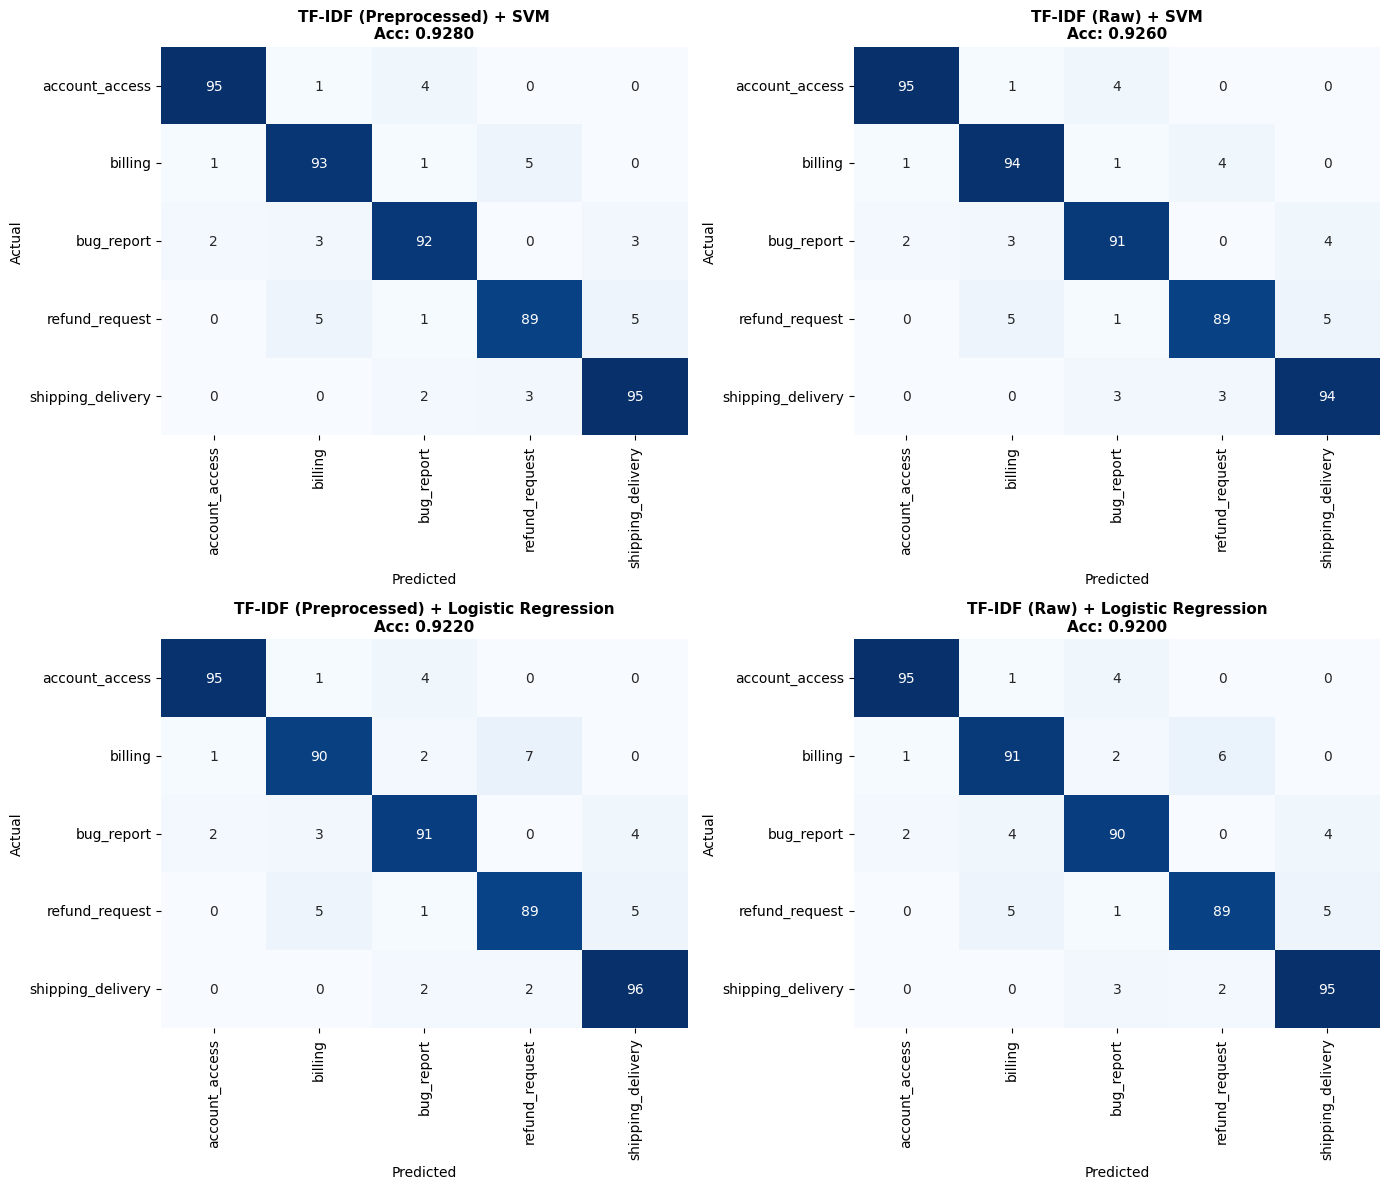

In [38]:
def get_predictions(feature_name, clf_name, X_train, X_test):
    if clf_name == 'SVM':
        clf = SVC(kernel='rbf')
    elif clf_name == 'Logistic Regression':
        clf = LogisticRegression(max_iter=1000)
    else:
        clf = KNeighborsClassifier(n_neighbors=5)
    
    clf.fit(X_train, y_train)
    return clf.predict(X_test)

feature_clf_map = {
    'TF-IDF (Preprocessed)': (X_train_tfidf_prep, X_test_tfidf_prep),
    'TF-IDF (Raw)': (X_train_tfidf_raw, X_test_tfidf_raw),
    'Word2Vec (Raw)': (X_train_embed_raw, X_test_embed_raw),
    'Word2Vec (Preprocessed)': (X_train_embed_prep, X_test_embed_prep),
    'FastText (Raw)': (X_train_embed_ft_raw, X_test_embed_ft_raw),
    'FastText (Preprocessed)': (X_train_embed_ft_prep, X_test_embed_ft_prep),
    'BERT (Raw)': (X_train_embed_bert_raw, X_test_embed_bert_raw),
    'BERT (Preprocessed)': (X_train_embed_bert_prep, X_test_embed_bert_prep),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (feature, clf, acc, f1) in enumerate(rankings[:4]):
    X_train, X_test = feature_clf_map[feature]
    y_pred = get_predictions(feature, clf, X_train, X_test)
    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=unique_labels,
        yticklabels=unique_labels,
        cbar=False
    )
    axes[idx].set_title(f'{feature} + {clf}\nAcc: {acc:.4f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()